# Project 5 - W-Shape Tension Member Automation

This notebook implements tensile yielding checks for W-shaped tension members based on AISC Chapter D logic used in your Methods section.

Outputs include:
- Required load (LRFD and ASD)
- Available strength (LRFD and ASD)
- Percent utilization (LRFD and ASD)
- Pass/Fail checks
- Two bar charts for LRFD and ASD utilization

In [16]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PHI_YIELDING = 0.90
OMEGA_YIELDING = 1.67
DEFAULT_ASTM = "A992"


@dataclass
class DesignInput:
    scenario: str
    shape: str
    material: str
    dead_load_kips: float
    live_load_kips: float

In [17]:
def load_shape_table(csv_path: str) -> pd.DataFrame:
    #Read only the first AISC label and first area column from the CSV.
    shapes = pd.read_csv(csv_path, usecols=[2, 5])
    shapes.columns = ["shape", "Ag"]
    shapes["shape"] = shapes["shape"].astype(str).str.strip().str.upper()
    shapes["Ag"] = pd.to_numeric(shapes["Ag"], errors="coerce")
    shapes = shapes.dropna(subset=["shape", "Ag"]).drop_duplicates(subset=["shape"])
    return shapes


def load_astm_table(csv_path: str) -> pd.DataFrame:
    #Read ASTM designation and Fy exactly as provided in your CSV.
    astm = pd.read_csv(csv_path, usecols=["ASTM Designation", "Fy"])
    astm.columns = ["material", "Fy"]
    astm["material"] = astm["material"].astype(str).str.strip().str.upper()
    astm["Fy"] = pd.to_numeric(astm["Fy"], errors="coerce")
    astm = astm.dropna(subset=["material", "Fy"]).drop_duplicates(subset=["material"])
    return astm


def get_ag(shape: str, shapes_df: pd.DataFrame) -> float:
    #Find gross area Ag from W_Shape_Table.csv.
    shape_clean = shape.strip().upper()
    row = shapes_df[shapes_df["shape"] == shape_clean]
    if row.empty:
        raise ValueError(f"Shape '{shape}' not found in W_Shape_Table.csv")
    return float(row.iloc[0]["Ag"])


def get_fy(material: str, astm_df: pd.DataFrame) -> tuple[str, float]:
    #Use A992 when material input is blank.
    material_clean = material.strip().upper()
    if material_clean == "":
        material_clean = DEFAULT_ASTM

    row = astm_df[astm_df["material"] == material_clean]
    if row.empty:
        raise ValueError(f"Material '{material_clean}' not found in ASTM_Material_Fy_Table.csv")
    return material_clean, float(row.iloc[0]["Fy"])


def tensile_yielding_check(D: float, L: float, Fy: float, Ag: float) -> dict:
    #AISC tensile yielding checks used in your Methods section.
    Pu = 1.2 * D + 1.6 * L
    Pa = D + L
    Pn = Fy * Ag
    phiPn = PHI_YIELDING * Pn
    Pallow = Pn / OMEGA_YIELDING

    u_lrfd = (Pu / phiPn) * 100
    u_asd = (Pa / Pallow) * 100

    return {
        "Pu (kips)": Pu,
        "Pa (kips)": Pa,
        "Pn (kips)": Pn,
        "phi*Pn (kips)": phiPn,
        "Pn/Omega (kips)": Pallow,
        "LRFD Utilization (%)": u_lrfd,
        "ASD Utilization (%)": u_asd,
        "LRFD Pass": "PASS" if phiPn >= Pu else "FAIL",
        "ASD Pass": "PASS" if Pallow >= Pa else "FAIL",
    }


def run_case(case: DesignInput, shapes_df: pd.DataFrame, astm_df: pd.DataFrame) -> dict:
    #Run one scenario and return one row of results.
    material_used, Fy = get_fy(case.material, astm_df)
    Ag = get_ag(case.shape, shapes_df)
    result = tensile_yielding_check(case.dead_load_kips, case.live_load_kips, Fy, Ag)

    return {
        "Scenario": case.scenario,
        "Shape": case.shape.strip().upper(),
        "Material": material_used,
        "Fy (ksi)": Fy,
        "Ag (in^2)": Ag,
        "D (kips)": case.dead_load_kips,
        "L (kips)": case.live_load_kips,
        **result,
    }


def evaluate_cases(cases: list[DesignInput], shapes_df: pd.DataFrame, astm_df: pd.DataFrame) -> pd.DataFrame:
    #Run all scenarios and combine into one table.
    rows = [run_case(case, shapes_df, astm_df) for case in cases]
    return pd.DataFrame(rows)

In [ ]:
#Use relative paths from PROJECT 5/Submissions notebook location.
shape_table_path = "../W_Shape_Table.csv"
astm_table_path = "../ASTM_Material_Fy_Table.csv"

#Load source tables.
shapes_df = load_shape_table(shape_table_path)
astm_df = load_astm_table(astm_table_path)

print(f"Loaded {len(shapes_df)} shapes from W_Shape_Table.csv")
print(f"Loaded {len(astm_df)} materials from ASTM_Material_Fy_Table.csv")


def prompt_shape() -> str:
    #Ask for a valid W-shape.
    while True:
        shape = input("Enter W-shape designation (example W12X50): ").strip()
        try:
            _ = get_ag(shape, shapes_df)
            return shape
        except ValueError:
            print("Shape not found. Try again.")


def prompt_material() -> str:
    #Blank input defaults to A992.
    while True:
        material = input("Enter ASTM material (blank defaults to A992): ").strip()
        try:
            material_used, _ = get_fy(material, astm_df)
            return material_used
        except ValueError:
            print("Material not found. Try again (example: A36 or A572 Gr.50).")


def prompt_nonnegative_float(label: str) -> float:
    #Ask for a nonnegative number.
    while True:
        try:
            value = float(input(label).strip())
            if value < 0:
                print("Value must be nonnegative.")
                continue
            return value
        except ValueError:
            print("Please enter a number.")


#Collect user scenario inputs.
user_case = DesignInput(
    scenario="User Input",
    shape=prompt_shape(),
    material=prompt_material(),
    dead_load_kips=prompt_nonnegative_float("Enter dead load D (kips): "),
    live_load_kips=prompt_nonnegative_float("Enter live load L (kips): "),
)

#Three comparison scenarios.
scenario_1 = DesignInput("Scenario 1", "W14X90", "A572 Gr.50", 150.0, 95.0)
scenario_2 = DesignInput("Scenario 2", "W10X30", "A36", 90.0, 60.0)
scenario_3 = DesignInput("Scenario 3", "W16X57", "A992", 110.0, 75.0)

#Run calculations.
results = evaluate_cases([user_case, scenario_1, scenario_2, scenario_3], shapes_df, astm_df)

#Display cleaned table.
formatted = results.copy()
num_cols = formatted.select_dtypes(include="number").columns
formatted[num_cols] = formatted[num_cols].round(2)

show_cols = [
    "Scenario", "Shape", "Material", "Ag (in^2)", "Fy (ksi)",
    "Pu (kips)", "Pa (kips)", "phi*Pn (kips)", "Pn/Omega (kips)",
    "LRFD Utilization (%)", "ASD Utilization (%)", "LRFD Pass", "ASD Pass"
]

print(formatted[show_cols].to_string(index=False))
results

Loaded 289 shapes from W_Shape_Table.csv
Loaded 13 materials from ASTM_Material_Fy_Table.csv
  Scenario  Shape   Material  Ag (in^2)  Fy (ksi)  Pu (kips)  Pa (kips)  phi*Pn (kips)  Pn/Omega (kips)  LRFD Utilization (%)  ASD Utilization (%) LRFD Pass ASD Pass
User Input W12X50       A992      14.60      50.0      200.0      150.0         657.00           437.13                 30.44                34.32      PASS     PASS
Scenario 1 W14X90 A572 GR.50      26.50      50.0      332.0      245.0        1192.50           793.41                 27.84                30.88      PASS     PASS
Scenario 2 W10X30        A36       8.84      32.0      204.0      150.0         254.59           169.39                 80.13                88.55      PASS     PASS
Scenario 3 W16X57       A992      16.80      50.0      252.0      185.0         756.00           502.99                 33.33                36.78      PASS     PASS


,Scenario,Shape,Material,Fy (ksi),Ag (in^2),D (kips),L (kips),Pu (kips),Pa (kips),Pn (kips),phi*Pn (kips),Pn/Omega (kips),LRFD Utilization (%),ASD Utilization (%),LRFD Pass,ASD Pass
0,User Input,W12X50,A992,50.0,14.60,100.0,50.0,200.0,150.0,730.00,657.000,437.125749,30.441400,34.315068,PASS,PASS
1,Scenario 1,W14X90,A572 GR.50,50.0,26.50,150.0,95.0,332.0,245.0,1325.00,1192.500,793.413174,27.840671,30.879245,PASS,PASS
2,Scenario 2,W10X30,A36,32.0,8.84,90.0,60.0,204.0,150.0,282.88,254.592,169.389222,80.128205,88.553450,PASS,PASS
3,Scenario 3,W16X57,A992,50.0,16.80,110.0,75.0,252.0,185.0,840.00,756.000,502.994012,33.333333,36.779762,PASS,PASS


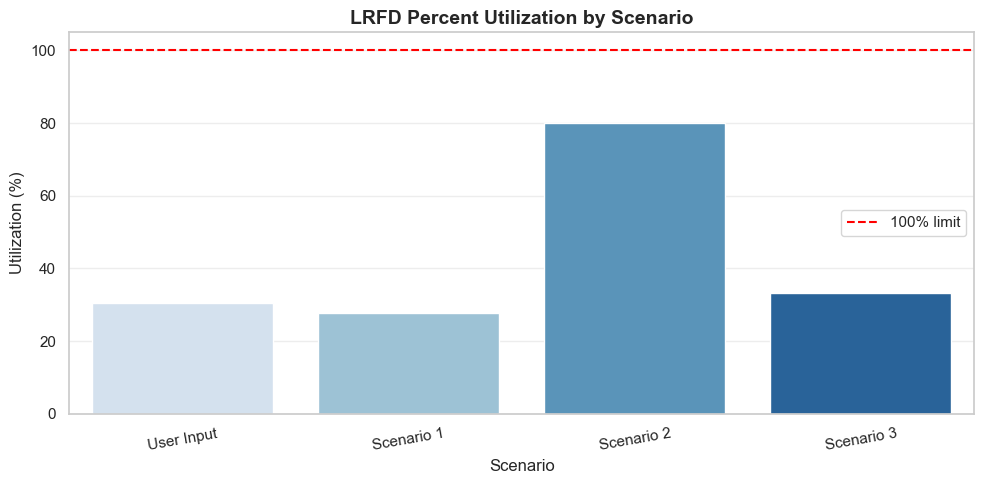

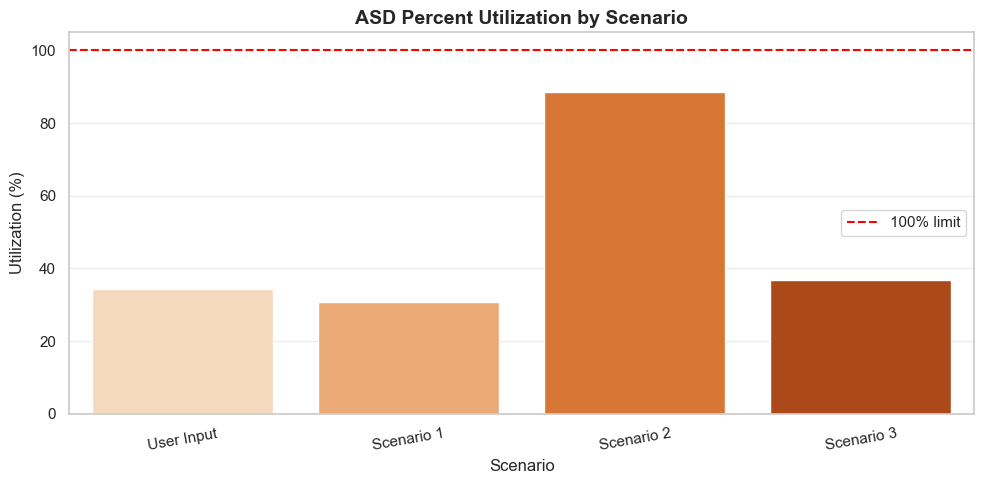

In [15]:
#Set plotting style.
sns.set_theme(style="whitegrid")

#LRFD utilization chart.
plt.figure(figsize=(10, 5))
sns.barplot(data=results, x="Scenario", y="LRFD Utilization (%)", hue="Scenario", palette="Blues", legend=False)
plt.axhline(100, color="red", linestyle="--", linewidth=1.5, label="100% limit")
plt.xlabel("Scenario")
plt.ylabel("Utilization (%)")
plt.title("LRFD Percent Utilization by Scenario", fontsize=14, fontweight="bold")
plt.xticks(rotation=10)
plt.grid(axis="y", alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

#ASD utilization chart.
plt.figure(figsize=(10, 5))
sns.barplot(data=results, x="Scenario", y="ASD Utilization (%)", hue="Scenario", palette="Oranges", legend=False)
plt.axhline(100, color="red", linestyle="--", linewidth=1.5, label="100% limit")
plt.xlabel("Scenario")
plt.ylabel("Utilization (%)")
plt.title("ASD Percent Utilization by Scenario", fontsize=14, fontweight="bold")
plt.xticks(rotation=10)
plt.grid(axis="y", alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()